In [ ]:
# Install torch 2.5 first (pinned)
!pip install -q torch==2.5.0 --index-url https://download.pytorch.org/whl/cu121

# PyG + geometric ops
!pip install -q torch_geometric
!pip install -q torch_cluster torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-2.5.0+cu121.html

# ASE
!pip install -q ase

# fairchem WITHOUT deps (so it doesn't upgrade torch)
!pip install -q --force-reinstall --no-deps "fairchem-core<2.0"

print("Installs done — RESTART THE RUNTIME before proceeding.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 82.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 55.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 94.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 13.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 10.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install -q lmdb
!pip install -q ase-db-backends

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 19.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fairchem-core 1.10.0 requires e3nn>=0.5, which is not installed.
fairchem-core 1.10.0 requires hydra-core, which is not installed.
fairchem-core 1.10.0 requires pymatgen>=2023.10.3, which is not installed.
fairchem-core 1.10.0 requires submitit, which is not installed.
fairchem-core 1.10.0 requires torchtnt, which is not installed.
fairchem-core 1.10.0 requires numpy<2.0.0,>=1.26.0, but you have numpy 2.0.2 which is incompatible.
fairchem-core 1.10.0 requires torch~=2.4.0, but you have torch 2.5.0+cu121 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 

In [ ]:
import sys
sys.path.insert(0, '/content')

# Import step by step to see where it fails
try:
    import torch
    print("✓ torch")
    from torch_geometric.nn import DimeNetPlusPlus
    print("✓ DimeNetPlusPlus")
    from fairchem.core.datasets import AseDBDataset
    print("✓ fairchem")
    from read_multi_ase import find_files, process_file
    print("✓ read_multi_ase")
    from extract import get_data, split_data, mol_to_data
    print("✓ extract")
    print("\nAll imports successful — process_file is now defined.")
except Exception as e:
    print(f"FAILED at: {type(e).__name__}: {e}")

✓ torch
✓ DimeNetPlusPlus
✓ fairchem
✓ read_multi_ase
✓ extract

All imports successful — process_file is now defined.


In [ ]:
from torch_geometric.loader import DataLoader

In [ ]:
!ls /content/

data0000.aselmdb  extract.py   read_multi_ase.py
data0001.aselmdb  __pycache__  sample_data


In [ ]:
bio_sample = process_file(file="/content/data0000.aselmdb", molecule_type="biomolecules", max_molecules=10000)
bio_data = get_data(bio_sample)
bio_train, bio_val = split_data(bio_data, 0.8)

bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)

Processed 10000 atoms


In [ ]:
class DimeNetPPModel(torch.nn.Module):
    def __init__(self,
                 hidden_channels: int = 64,
                 out_channels: int = 1,
                 num_blocks: int = 3,
                 int_emb_size: int = 64,
                 basis_emb_size: int = 8,
                 out_emb_channels: int = 128,
                 num_spherical: int = 7,
                 num_radial: int = 6,
                 cutoff: float = 5.0,
                 max_num_neighbors: int = 32):
        super().__init__()
        self.dimenet = DimeNetPlusPlus(
            hidden_channels=hidden_channels,
            out_channels=out_channels,
            num_blocks=num_blocks,
            int_emb_size=int_emb_size,
            basis_emb_size=basis_emb_size,
            out_emb_channels=out_emb_channels,
            num_spherical=num_spherical,
            num_radial=num_radial,
            cutoff=cutoff,
            max_num_neighbors=max_num_neighbors,
        )

    def forward(self, data):
        out = self.dimenet(data.z, data.pos, batch=data.batch)
        return out


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bio_model = DimeNetPPModel().to(device)
optimizer = torch.optim.Adam(bio_model.parameters(), lr=1e-4)
loss_fn = torch.nn.SmoothL1Loss()

print(f"Device: {device}")
print(f"Params: {sum(p.numel() for p in bio_model.parameters()):,}")


def train(model, train_data):
    model.train()
    total_loss = 0
    for data in train_data:
        data = data.to(device)
        optimizer.zero_grad()
        pred = model(data)
        loss = loss_fn(pred, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_data)


@torch.no_grad()
def evaluate(model, val_data):
    model.eval()
    total_loss = 0
    for data in val_data:
        data = data.to(device)
        pred = model(data)
        loss = loss_fn(pred, data.y)
        total_loss += loss.item()
    return total_loss / len(val_data)


@torch.no_grad()
def test(model, test_data):
    model.eval()
    total_mae = 0
    total_mse = 0
    total_samples = 0
    for data in test_data:
        data = data.to(device)
        pred = model(data)
        target = data.y.view(-1, 1)
        mae = torch.abs(pred - target).sum()
        mse = ((pred - target) ** 2).sum()
        total_mae += mae.item()
        total_mse += mse.item()
        total_samples += target.size(0)
    mean_mae = total_mae / total_samples
    rmse = (total_mse / total_samples) ** 0.5
    return mean_mae, rmse

Device: cuda
Params: 392,966


In [ ]:
import numpy as np

epochs = 100
bio_train_losses = np.zeros(epochs)
bio_val_losses = np.zeros(epochs)

for epoch in range(epochs):
    train_loss = train(bio_model, bio_train_loader)
    val_loss = evaluate(bio_model, bio_val_loader)

    bio_train_losses[epoch] = train_loss
    bio_val_losses[epoch] = val_loss
    if epoch % 5 == 0:
        print(f"Epoch {epoch + 1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1040: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.smooth_l1_loss(input, target, reduction=self.reduction, beta=self.beta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1040: UserWarning: Using a target size (torch.Size([16])) that is different to the input size (torch.Size([16, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.smooth_l1_loss(input, target, reduction=self.reduction, beta=self.beta)


Epoch 001 | Train Loss: 3.4906 | Val Loss: 2.3914
Epoch 006 | Train Loss: 1.7225 | Val Loss: 1.6718
Epoch 011 | Train Loss: 1.5306 | Val Loss: 1.4681
Epoch 016 | Train Loss: 1.4662 | Val Loss: 1.7076
Epoch 021 | Train Loss: 1.4021 | Val Loss: 1.3695
Epoch 026 | Train Loss: 1.3450 | Val Loss: 1.4453
Epoch 031 | Train Loss: 1.3060 | Val Loss: 1.4745
Epoch 036 | Train Loss: 1.2676 | Val Loss: 1.3459
Epoch 041 | Train Loss: 1.2338 | Val Loss: 1.3458
Epoch 046 | Train Loss: 1.1811 | Val Loss: 1.3497
Epoch 051 | Train Loss: 1.1416 | Val Loss: 1.3397
Epoch 056 | Train Loss: 1.1171 | Val Loss: 1.3532
Epoch 061 | Train Loss: 1.1047 | Val Loss: 1.3581
Epoch 066 | Train Loss: 1.0871 | Val Loss: 1.3888
Epoch 071 | Train Loss: 1.0847 | Val Loss: 1.3865
Epoch 076 | Train Loss: 1.0761 | Val Loss: 1.3840
Epoch 081 | Train Loss: 1.0669 | Val Loss: 1.4114
Epoch 086 | Train Loss: 1.0697 | Val Loss: 1.3849
Epoch 091 | Train Loss: 1.0493 | Val Loss: 1.5147
Epoch 096 | Train Loss: 1.0399 | Val Loss: 1.4306


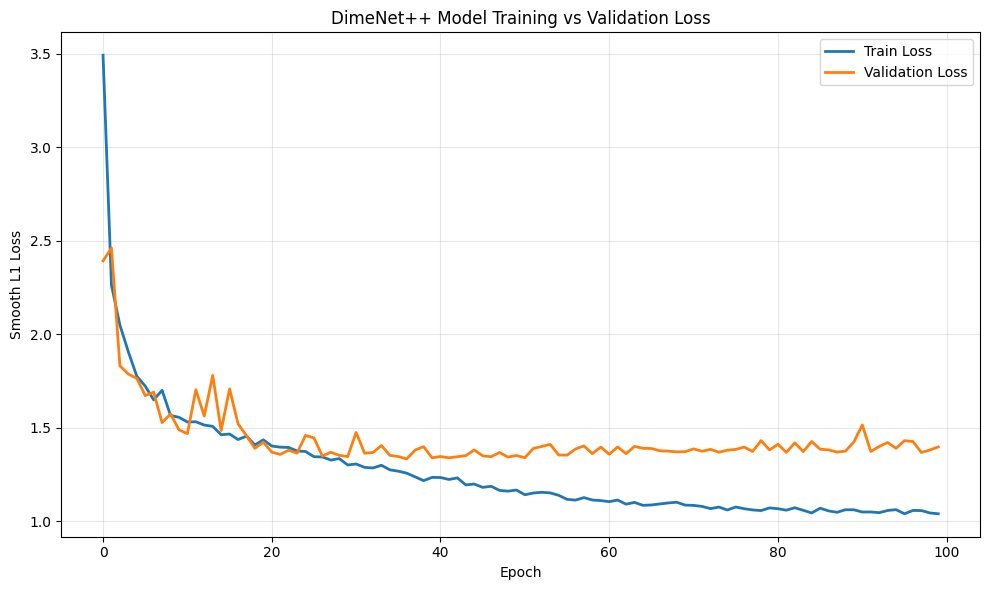


Final Train Loss: 1.0398
Final Val Loss:   1.3971
Best Val Loss:    1.3331 at epoch 37


In [ ]:
# Plot loss curves (same style as SchNet notebook)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(bio_train_losses, label='Train Loss', linewidth=2)
plt.plot(bio_val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Smooth L1 Loss')
plt.title('DimeNet++ Model Training vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFinal Train Loss: {bio_train_losses[-1]:.4f}")
print(f"Final Val Loss:   {bio_val_losses[-1]:.4f}")
print(f"Best Val Loss:    {bio_val_losses.min():.4f} at epoch {bio_val_losses.argmin() + 1}")

In [ ]:
from google.colab import files
import json

history = {
    'train_loss': bio_train_losses.tolist(),
    'val_loss': bio_val_losses.tolist(),
    'best_val_loss': float(bio_val_losses.min()),
    'best_val_epoch': int(bio_val_losses.argmin() + 1),
    'final_train_loss': float(bio_train_losses[-1]),
    'final_val_loss': float(bio_val_losses[-1]),
}
with open('/content/dimenet_matched_history.json', 'w') as f:
    json.dump(history, f, indent=2)

# Also save the plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(bio_train_losses, label='Train Loss', linewidth=2)
plt.plot(bio_val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (SmoothL1)')
plt.title('DimeNet++ Model Training vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/dimenet_curves.png', dpi=150, bbox_inches='tight')
plt.close()

files.download('/content/dimenet_matched_history.json')
files.download('/content/dimenet_curves.png')

print("Saved and downloading.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloading.


In [ ]:
# Test on held-out data — same file and setup as SchNet notebook
bio_testing = process_file(file="./data0001.aselmdb", molecule_type="biomolecules", max_molecules=200)
bio_test_data = get_data(bio_testing)
bio_test_loader = DataLoader(bio_test_data, batch_size=32)

mae, rmse = test(bio_model, bio_test_loader)
print(f"Test MAE: {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Processed 200 atoms
Test MAE: 1.9555
Test RMSE: 2.7070
